## Обучение с учителем. Задача регрессии. Решающие деревья. Ансамбли моделей

In [1]:
import pandas as pd
import optuna
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

### Чтение данных

In [2]:
data = pd.read_csv("../data/diamonds_filtered.csv")
data.head(10)

,carat,cut,color,clarity,depth,table,price,radius
0,0.29,4,2,4,62.4,58,334,2.100
1,0.31,2,1,2,63.3,58,335,2.170
2,0.30,2,1,3,64.0,55,339,2.125
3,0.31,5,1,2,62.2,54,344,2.175
4,0.32,4,6,1,60.9,58,345,2.190
5,0.30,5,2,2,62.0,54,348,2.155
6,0.30,2,1,3,63.4,54,351,2.115
7,0.30,2,1,3,63.8,56,351,2.115
8,0.30,3,1,3,62.7,59,351,2.105
9,0.30,2,2,2,63.3,56,351,2.130


### Выделение целевого признака и предиктора

In [3]:
y = data['price']
x = data.drop('price', axis=1)

### Обучение DecisionTreeRegressor 

Включает в себя:
- использование `Pipeline`
- стандартизацию данных при помощи `StandardScaler`
- кросс-валидацию через `KFold`
- подбор гиперпараметров при помощи фреймворка `Optuna`

In [4]:
def objective(trial):
    params = {
        'criterion': trial.suggest_categorical('criterion', ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 5, 25),
        'random_state': 81,
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.1),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.01)
    }

    # pipeline = Pipeline([
    #     ('scaler', StandardScaler()),
    #     ('dtr', DecisionTreeRegressor(**params))
    # ])

    model = DecisionTreeRegressor(**params)

    kf = KFold(n_splits=5, shuffle=True, random_state=81)

    score = cross_val_score(
        model, x, y, cv=kf,
        scoring='r2',
        n_jobs=-1
    )

    return score.mean()

In [5]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, n_jobs=-1)

[I 2026-04-10 08:32:05,179] A new study created in memory with name: no-name-718a5086-f12a-41d9-a476-35ebc820eb1c
[I 2026-04-10 08:32:06,825] Trial 6 finished with value: 0.8994874415022828 and parameters: {'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 12, 'min_samples_leaf': 15, 'max_leaf_nodes': 9, 'min_impurity_decrease': 0.05806764179040622, 'ccp_alpha': 0.009855124892066329}. Best is trial 6 with value: 0.8994874415022828.
[I 2026-04-10 08:32:06,840] Trial 9 finished with value: 0.9331055516408631 and parameters: {'criterion': 'friedman_mse', 'max_depth': 10, 'min_samples_split': 27, 'min_samples_leaf': 9, 'max_leaf_nodes': 17, 'min_impurity_decrease': 0.025411660171607644, 'ccp_alpha': 0.0006025000474428254}. Best is trial 9 with value: 0.9331055516408631.
[I 2026-04-10 08:32:06,877] Trial 5 finished with value: 0.907475665233148 and parameters: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 24, 'min_samples_leaf': 9, 'max_leaf_nodes': 10

In [6]:
print(f"Best params: {study.best_params}")
print(f"Best R^2: {round(study.best_value, 4)}")

Best params: {'criterion': 'friedman_mse', 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_leaf_nodes': 25, 'min_impurity_decrease': 0.07285164112567423, 'ccp_alpha': 0.0022976134040062417}
Best R^2: 0.9455


### Метрики

In [14]:
# best_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('dtr', DecisionTreeRegressor(**study.best_params, random_state=81))
# ])
# model = DecisionTreeRegressor(**study.best_params, random_state=81)
# model.fit(x, y)

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=81
)

model = DecisionTreeRegressor(**study.best_params, random_state=81)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

metrics = {
    'Model': 'DTR Optimized',
    'MAE': round(mean_absolute_error(y_test, y_pred), 4),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
    'MAPE': round(mean_absolute_percentage_error(y_test, y_pred), 4),
    'R2 (Test)': round(model.score(x_test, y_test), 5),
    'R2 (CV)': round(study.best_value, 5) 
}

In [15]:
res = pd.DataFrame([metrics])
res

,Model,MAE,RMSE,MAPE,R2 (Test),R2 (CV)
0,DTR Optimized,509.6697,821.1949,0.1865,0.94711,0.94551


- `MAE` = 509.7 $\rightarrow$ В среднем модель ошибается на 510 единиц
- `RMSE` = 821.2 $\rightarrow$ Свидетельствует о том, что в моделе есть несколько объектов, где она она ошиблась сильно, но их немного
- `MAPE` = 0.1865 $\rightarrow$ В среднем предсказание отклоняется от реальной цены на 18.7%
- $R^2$ (Test) = 0.947 $\rightarrow$ Качество на тестовой выборке
- $R^2$ (CV) = 0.95 $\rightarrow$ Среднее качество по кросс-валидации

### Визуализация

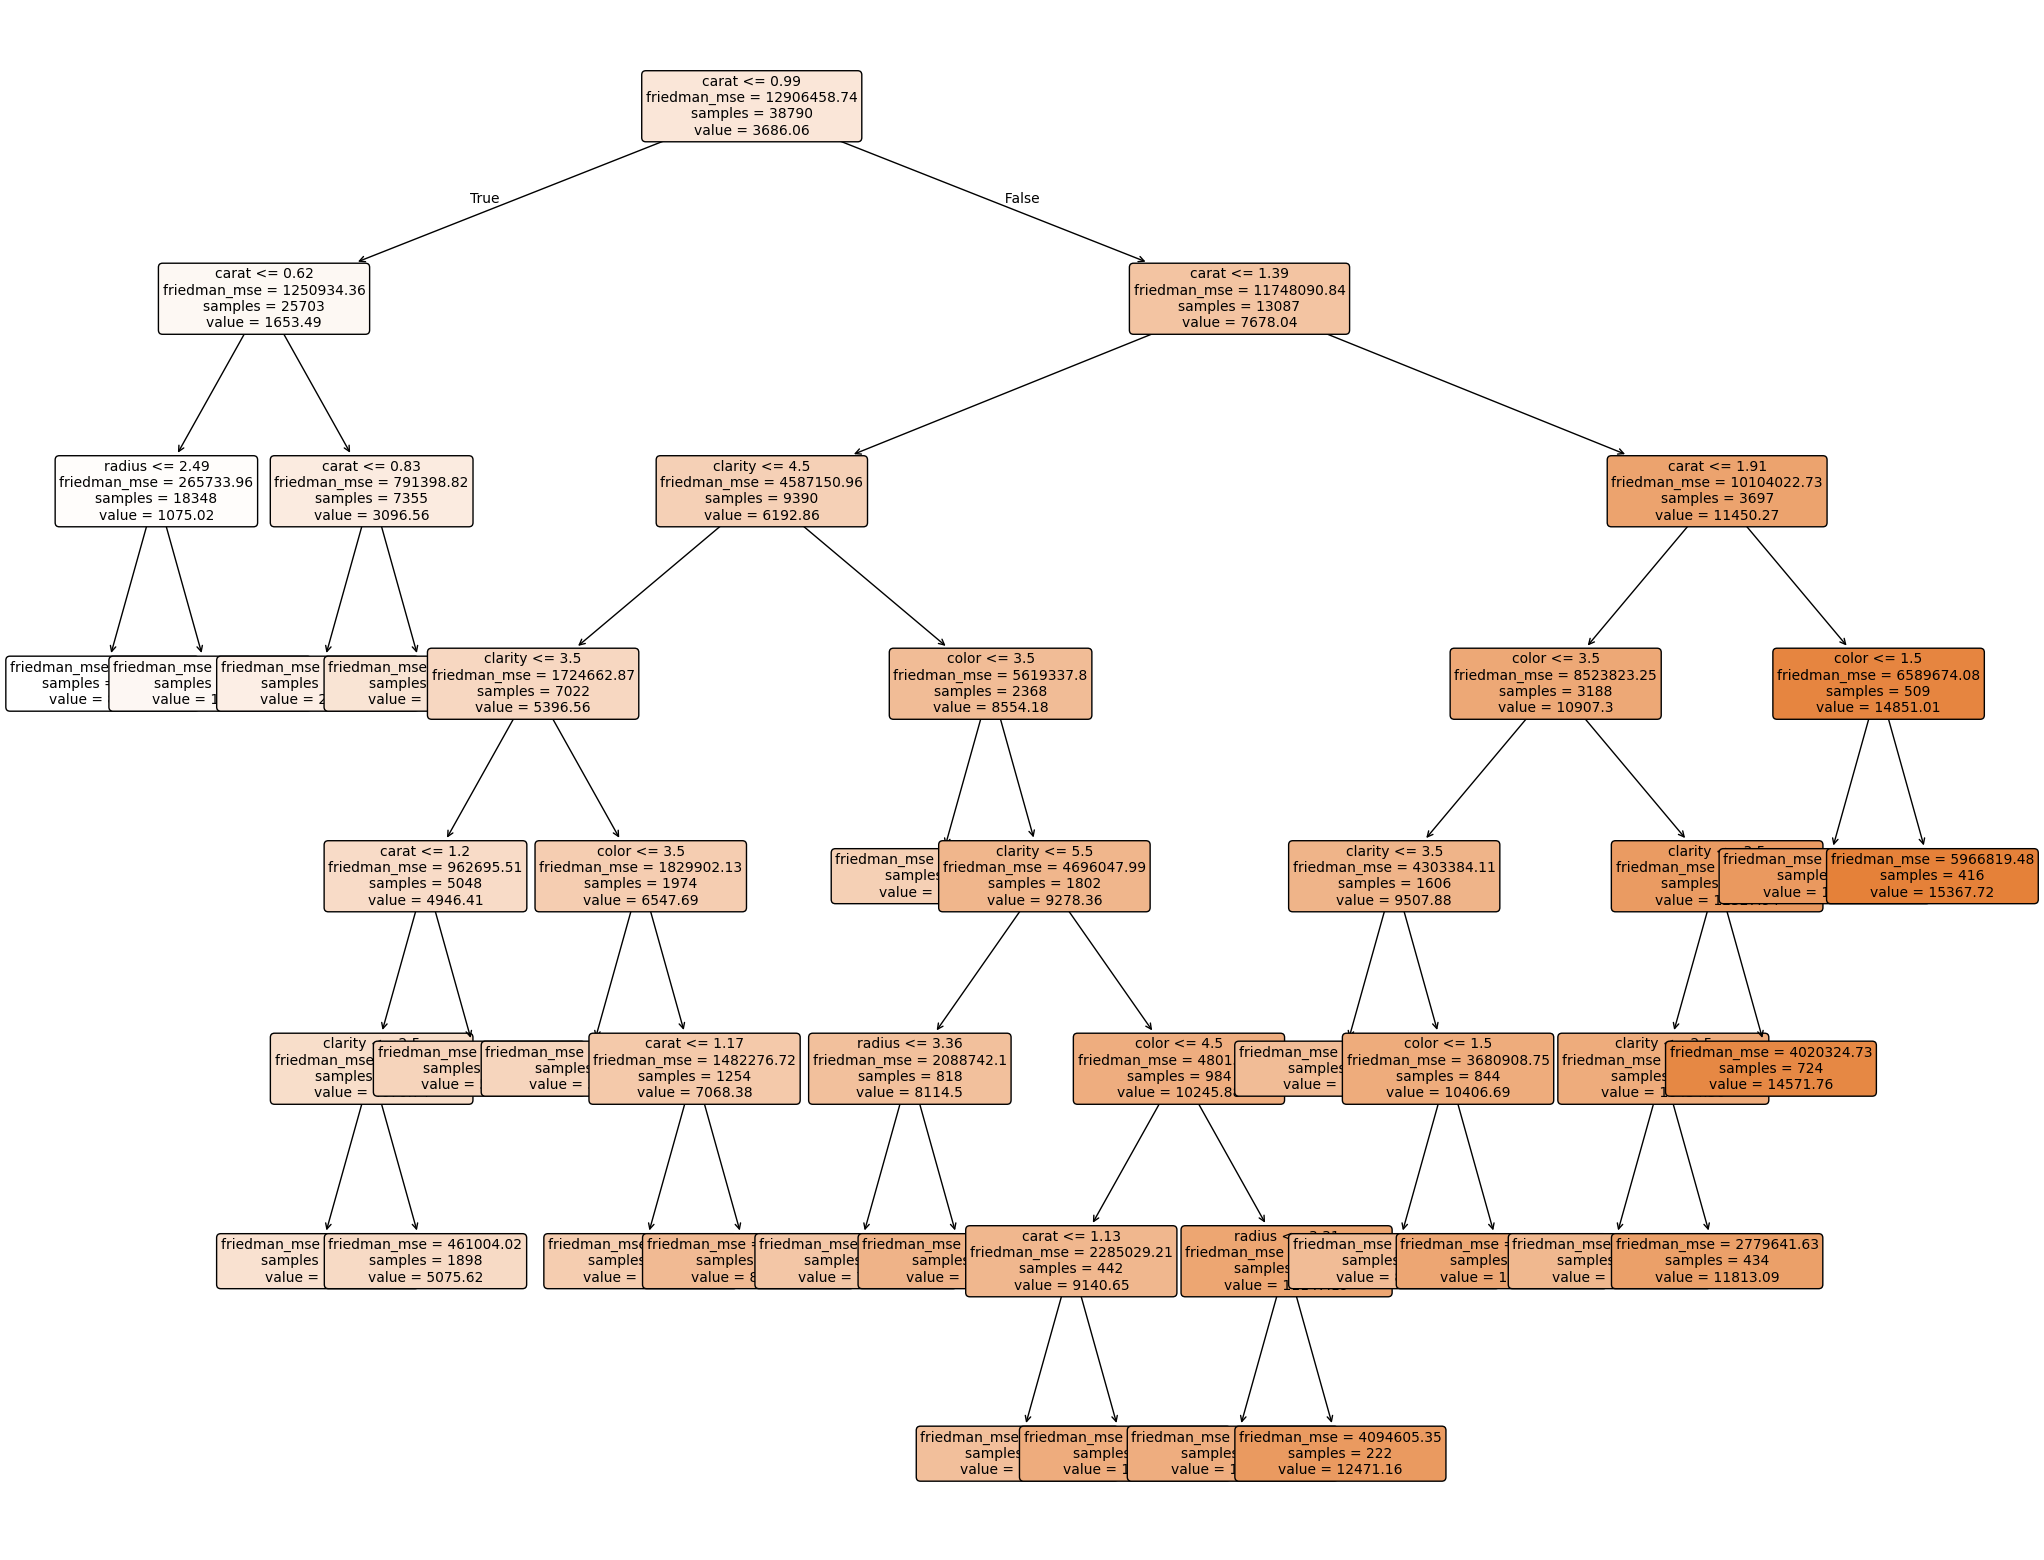

In [16]:
fig = plt.figure(figsize=(25, 20), facecolor='white')
ax = fig.add_subplot(111)

plot_tree(model, 
          feature_names=list(x.columns), 
          filled=True, 
          rounded=True, 
          precision=2, 
          fontsize=10,
          ax=ax)

plt.show()

### Вывод

В ходе выполнения работы была построена и оптимизирована модель регрессии на основе решающих деревьев. Использование фреймворка Optuna и метода кросс-валидации (`K`=5) позволило подобрать гиперпараметры, обеспечивающие высокую обобщающую способность. 

Модель объясняет 95% дисперсии целевого признака (согласно метрике $R^2$), что свидетельствует о высокой точности аппроксимации данных. Близость значений $R^2$ на кросс-валидации и на полной выборке (разница менее 0.1%) подтверждает устойчивость модели и отсутствие эффекта переобучения. 

Средняя относительная ошибка (`MAPE` = 18.7%) позволяет охарактеризовать качество прогнозирования как "хорошее".